# Assignment 10

## Disclaimer
As we are using dagshub we have a separate file for testing different hyperparameters but this file does the same thing only that it does not include the dagshub connection making it runnable on other computers.

## How to run:
The data folder that is needed is submitted together in the zip file that was handed in, this is beacuse we have already mapped the data to mediapipe. The file for mirroring the data is not included in this but is handled in a separate file for this asssignment.
All paths should be correct if run correctly, the config is set to some experiment.
Results of more experiments are placed at the bottom of this file.
To run the notebook just press run all.

Total Files: 358
Train: 218, Val: 70, Test: 35
Epoch 0: Train MSE 0.008488, Val MAE 0.054702
Epoch 1: Train MSE 0.005143, Val MAE 0.056432
Epoch 2: Train MSE 0.003654, Val MAE 0.045157
Epoch 3: Train MSE 0.002468, Val MAE 0.042242
Epoch 4: Train MSE 0.002071, Val MAE 0.041268
Epoch 5: Train MSE 0.002089, Val MAE 0.038440
Epoch 6: Train MSE 0.001250, Val MAE 0.036776
Epoch 7: Train MSE 0.001135, Val MAE 0.038877
Epoch 8: Train MSE 0.000847, Val MAE 0.036824
Epoch 9: Train MSE 0.001069, Val MAE 0.040844
Epoch 10: Train MSE 0.000956, Val MAE 0.034436
Epoch 11: Train MSE 0.000699, Val MAE 0.037653
Epoch 12: Train MSE 0.000540, Val MAE 0.035281
Epoch 13: Train MSE 0.000409, Val MAE 0.034664
Epoch 14: Train MSE 0.000922, Val MAE 0.035701
Epoch 15: Train MSE 0.000324, Val MAE 0.034065
Epoch 16: Train MSE 0.000358, Val MAE 0.036879
Epoch 17: Train MSE 0.001837, Val MAE 0.032359
Epoch 18: Train MSE 0.000352, Val MAE 0.032551
Epoch 19: Train MSE 0.000906, Val MAE 0.034449
Epoch 20: Train MSE 0.0

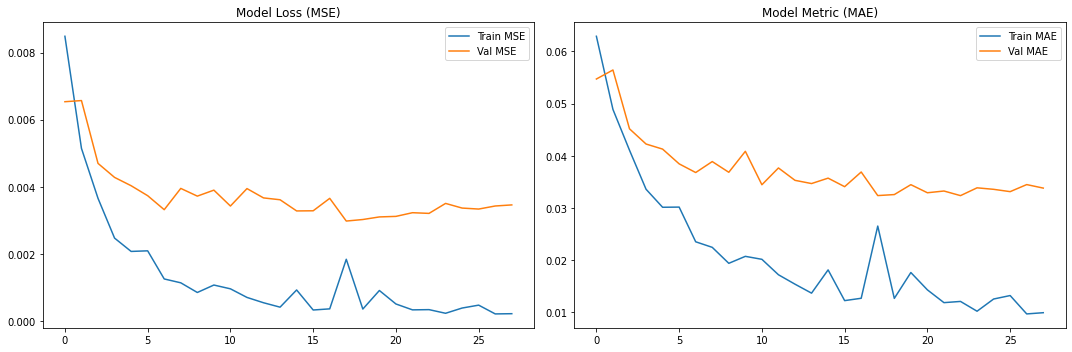

In [1]:
import torch
import torch.nn as nn
from torch.utils.data import Dataset, DataLoader
import pandas as pd
import numpy as np
import os
import glob
import matplotlib.pyplot as plt
import random

config = {
    "variant": "LSTM-Z-Lifting-Mirror-Augmentation",
    "seq_length": 30,
    "batch_size": 32,
    "hidden_size": 128,
    "num_layers": 2,
    "learning_rate": 0.005,
    "rnn_type": 'LSTM',
    "epochs": 50,
    "patience": 10,
    "seed": 42
}

SEED = config["seed"]
random.seed(SEED)
np.random.seed(SEED)
torch.manual_seed(SEED)
if torch.cuda.is_available():
    torch.cuda.manual_seed_all(SEED)

torch.backends.cudnn.deterministic = True
torch.backends.cudnn.benchmark = False

class KinectFolderDataset(Dataset):
    def __init__(self, file_paths, seq_length=30):
        self.X_seqs = []
        self.y_seqs = []
        self.seq_length = seq_length

        for path in file_paths:
            df = pd.read_csv(path)
            all_cols = [c for c in df.columns if c != 'FrameNo']
            x_y_cols = sorted([c for c in all_cols if c.endswith('_x') or c.endswith('_y')])
            z_cols = sorted([c for c in all_cols if c.endswith('_z')])
            
            x_data = df[x_y_cols].values.astype(np.float32)
            y_data = df[z_cols].values.astype(np.float32)
            
            if len(df) >= seq_length:
                for i in range(len(df) - seq_length + 1):
                    self.X_seqs.append(x_data[i : i + seq_length])
                    self.y_seqs.append(y_data[i : i + seq_length])
            
    def __len__(self): return len(self.X_seqs)
    def __getitem__(self, idx):
        return torch.tensor(self.X_seqs[idx]), torch.tensor(self.y_seqs[idx])

class PoseLiftingModel(nn.Module):
    def __init__(self, input_size=26, hidden_size=128, num_layers=2, output_size=13, rnn_type='LSTM'):
        super(PoseLiftingModel, self).__init__()
        if rnn_type == 'LSTM':
            self.rnn = nn.LSTM(input_size, hidden_size, num_layers, batch_first=True)
        else:
            self.rnn = nn.GRU(input_size, hidden_size, num_layers, batch_first=True)
        self.fc = nn.Linear(hidden_size, output_size)
        self.relu = nn.ReLU()

    def forward(self, x):
        out, _ = self.rnn(x)
        out = self.relu(out)
        return self.fc(out)

folder = "datafiles/kinect_good_preprocessed_A9_mediapipe"
all_files = sorted(glob.glob(os.path.join(folder, "*.csv")))

originals = [f for f in all_files if "_mirrored" not in f]
np.random.shuffle(originals)

num_total = len(all_files)
num_test = int(0.1 * num_total)
num_val = int(0.1 * num_total)

test_files_orig = originals[:num_test]
val_files_orig = originals[num_test : num_test + num_val]
train_files_orig = originals[num_test + num_val:]

def add_mirrors(file_list):
    augmented = []
    for f in file_list:
        augmented.append(f)
        mirror = f.replace(".csv", "_mirrored.csv")
        if os.path.exists(mirror):
            augmented.append(mirror)
    return augmented

train_files = add_mirrors(train_files_orig)
val_files = add_mirrors(val_files_orig)
test_files = test_files_orig 

print(f"Total Files: {num_total}")
print(f"Train: {len(train_files)}, Val: {len(val_files)}, Test: {len(test_files)}")

train_dataset = KinectFolderDataset(train_files, seq_length=config["seq_length"])
val_dataset   = KinectFolderDataset(val_files, seq_length=config["seq_length"])
test_dataset  = KinectFolderDataset(test_files, seq_length=config["seq_length"])

train_loader = DataLoader(train_dataset, batch_size=config["batch_size"], shuffle=True)
val_loader   = DataLoader(val_dataset, batch_size=config["batch_size"], shuffle=False)
test_loader  = DataLoader(test_dataset, batch_size=1, shuffle=False)

device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
model = PoseLiftingModel(
    input_size=26, 
    hidden_size=config["hidden_size"], 
    num_layers=config["num_layers"], 
    output_size=13, 
    rnn_type=config["rnn_type"]
).to(device)

criterion = nn.MSELoss() 
optimizer = torch.optim.Adam(model.parameters(), lr=config["learning_rate"])

history = {'train_mse': [], 'val_mse': [], 'train_mae': [], 'val_mae': []}
best_val_loss = float('inf')
counter = 0

for epoch in range(config["epochs"]):
    model.train()
    train_running_loss = 0.0
    train_running_mae = 0.0
    
    for inputs, targets in train_loader:
        inputs, targets = inputs.to(device), targets.to(device)
        optimizer.zero_grad()
        outputs = model(inputs)
        loss = criterion(outputs, targets)
        loss.backward()
        optimizer.step()
        train_running_loss += loss.item()
        train_running_mae += torch.mean(torch.abs(outputs - targets)).item()
    
    model.eval()
    val_running_loss = 0.0
    val_running_mae = 0.0
    with torch.no_grad():
        for inputs, targets in val_loader:
            inputs, targets = inputs.to(device), targets.to(device)
            outputs = model(inputs)
            v_loss = criterion(outputs, targets)
            val_running_loss += v_loss.item()
            val_running_mae += torch.mean(torch.abs(outputs - targets)).item()
            
    epoch_metrics = {
        "train_mse": train_running_loss / len(train_loader),
        "val_mse": val_running_loss / len(val_loader),
        "train_mae": train_running_mae / len(train_loader),
        "val_mae": val_running_mae / len(val_loader)
    }
    
    for k in history.keys():
        history[k].append(epoch_metrics[k])
        
    print(f"Epoch {epoch}: Train MSE {epoch_metrics['train_mse']:.6f}, Val MAE {epoch_metrics['val_mae']:.6f}")

    if epoch_metrics["val_mse"] < best_val_loss:
        best_val_loss = epoch_metrics["val_mse"]
        counter = 0
        torch.save(model.state_dict(), 'best_model.pth')
    else:
        counter += 1
        if counter >= config["patience"]:
            print("Early stopping triggered.")
            break

print("\n--- Running Final Evaluation ---")
joint_names = [
    "nose", "left_shoulder", "left_elbow", "right_shoulder", "right_elbow",
    "left_wrist", "right_wrist", "left_hip", "right_hip", "left_knee", 
    "right_knee", "left_ankle", "right_ankle"
]

all_seq_errors = []
joint_error_accumulator = {name: [] for name in joint_names}

model.load_state_dict(torch.load('best_model.pth'))
model.eval()
with torch.no_grad():
    for inputs, targets in test_loader:
        inputs, targets = inputs.to(device), targets.to(device)
        predictions = model(inputs)
        
        dist_cm = torch.abs(predictions - targets) * 100
        all_seq_errors.append(torch.mean(dist_cm).item())
        
        error_per_joint = torch.mean(dist_cm, dim=(0, 1)).cpu().numpy()
        for i, name in enumerate(joint_names):
            joint_error_accumulator[name].append(error_per_joint[i])

grand_average = np.mean(all_seq_errors)
print(f"Evaluation Complete. Grand Avg Error: {grand_average:.3f} cm")

fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(15, 5))
ax1.plot(history['train_mse'], label='Train MSE'); ax1.plot(history['val_mse'], label='Val MSE')
ax1.set_title('Model Loss (MSE)'); ax1.legend()
ax2.plot(history['train_mae'], label='Train MAE'); ax2.plot(history['val_mae'], label='Val MAE')
ax2.set_title('Model Metric (MAE)'); ax2.legend()
plt.tight_layout()
plt.savefig("z_learning_plots.png")

pd.DataFrame(history).to_csv("training_history.csv", index=False)
mean_joint_errors = {name: np.mean(joint_error_accumulator[name]) for name in joint_names}
pd.DataFrame.from_dict(mean_joint_errors, orient='index', columns=['Mean_Error_cm']).to_csv("per_joint_evaluation.csv")

## Experiments
Check the following link for experiments, those named Z-Depth-Training is relevant for this.

[Link to experiments on dagshub](https://dagshub.com/SamuelFredricBerg/4dt907/experiments)